Importando as coisas

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from datetime import datetime, timedelta

Agora vamos criar o vendas.csv assim como a questao 2 pede

In [2]:
np.random.seed(42)
data = [datetime(2023, 1, 1) + timedelta(days=random.randint(0, 365)) for _ in range(200)]
loja = np.random.choice(['Loja da Isabela', 'Loja do Francisco', 'Loja do Hugo', 'Loja do Parreira'], 200)
regiao = np.random.choice(['Barroca', 'Savassi', 'Lourdes', 'Barro Preto'], 200) 
produto = np.random.choice(['Pipoca Doce', 'Açaí', 'Sorvete', 'Pizza Doce', 'Chocolate'], 200)
categoria = np.random.choice(['Doces Caseiros', 'Doces Frios', 'Pizza'], 200) 
quantidade = np.random.randint(1, 15, 200).astype(float)
preco = np.random.uniform(50, 100, 200)

In [3]:
df_fake = pd.DataFrame({
    'data': data,
    'loja': loja,
    'regiao': regiao,
    'produto': produto,
    'categoria': categoria,
    'quantidade': quantidade,
    'preco_unitario': preco
})

df_fake.loc[5:10, 'quantidade'] = np.nan
df_fake.loc[20:25, 'preco_unitario'] = np.nan

df_fake.to_csv('vendas.csv', index=False)

In [4]:
df = pd.read_csv('vendas.csv')
df['data'] = pd.to_datetime(df['data'])

# Criar a coluna faturamento (questao 3)
df['faturamento'] = df['quantidade'] * df['preco_unitario']

print(" ")
print("-------------- Infos --------------")
df.info()
print(" ")
print("\n-------------- Valores Ausentes --------------")
print(df.isnull().sum())
print(" ")
print("\n-------------- Resumo Estátistico --------------")
print(df.describe())

 
-------------- Infos --------------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            200 non-null    datetime64[us]
 1   loja            200 non-null    str           
 2   regiao          200 non-null    str           
 3   produto         200 non-null    str           
 4   categoria       200 non-null    str           
 5   quantidade      194 non-null    float64       
 6   preco_unitario  194 non-null    float64       
 7   faturamento     188 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 12.6 KB
 

-------------- Valores Ausentes --------------
data               0
loja               0
regiao             0
produto            0
categoria          0
quantidade         6
preco_unitario     6
faturamento       12
dtype: int64
 

-------------- Resumo Estátistico -------------

In [5]:
media_qtd = df['quantidade'].mean()
media_preco = df['preco_unitario'].mean()

df['quantidade'] = df['quantidade'].fillna(media_qtd)
df['preco_unitario'] = df['preco_unitario'].fillna(media_preco)

In [6]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
print("\nArrumando os valores nulos")


Arrumando os valores nulos


## Etapa 2:

In [7]:
faturamentoloja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
print("---------------------------------")
print(faturamentoloja)  

---------------------------------
loja
Loja do Hugo        29091.46
Loja do Francisco   28073.59
Loja da Isabela     24519.25
Loja do Parreira    22751.55
Name: faturamento, dtype: float64


In [8]:
ticketmedio = (df.groupby('loja')['faturamento'].sum() / df.groupby('loja')['faturamento'].count())
print("\n---------------------------------")
print(ticketmedio)


---------------------------------
loja
Loja da Isabela     533.03
Loja do Francisco   610.30
Loja do Hugo        538.73
Loja do Parreira    421.33
Name: faturamento, dtype: float64


In [9]:
topprodutos = df.groupby('produto')['quantidade'].sum().nlargest(5)
print("\n-------------------------")
print(topprodutos)


-------------------------
produto
Açaí          325.91
Pipoca Doce   276.82
Pizza Doce    268.00
Chocolate     264.91
Sorvete       246.82
Name: quantidade, dtype: float64


In [10]:
df['mes_ano'] = df['data'].dt.strftime('%m/%Y')
faturamento_meseano = df.groupby('mes_ano')['faturamento'].sum()

mes_maior_fat = faturamento_meseano.idxmax()
mes_menor_fat = faturamento_meseano.idxmin()
print(f"\n------------- Mensal -------------")
print(f"Mês com maior faturamento: {mes_maior_fat}")
print(f"Mês com menor faturamento: {mes_menor_fat}")


------------- Mensal -------------
Mês com maior faturamento: 11/2023
Mês com menor faturamento: 05/2023


In [11]:
df['mes'] = df['data'].dt.month
print("\nColuna mês adicionada.")


Coluna mês adicionada.


## Etapa 3

C:\Users\22400206\AppData\Local\Temp\ipykernel_8816\2887862465.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faturamento_loja.index, y=faturamento_loja.values, palette='viridis')


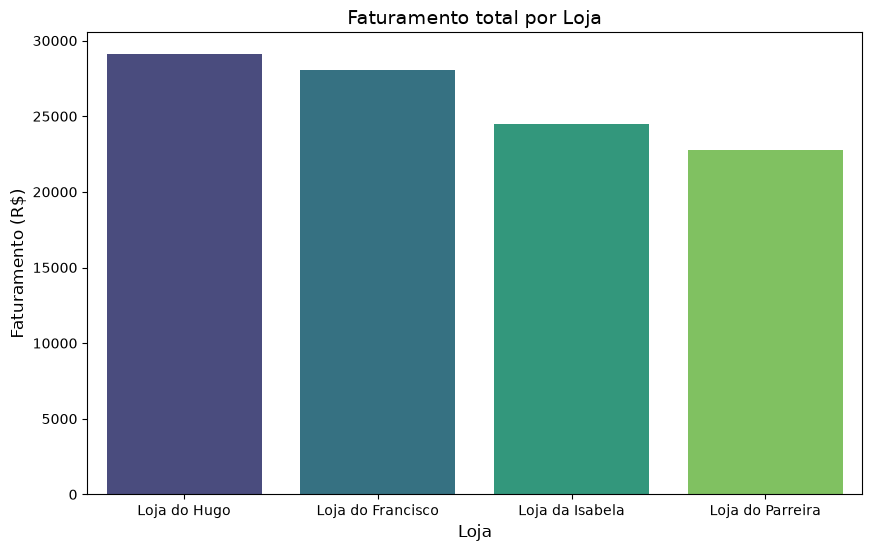

In [12]:
# 11

plt.figure(figsize=(10, 6))

faturamento_loja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
sns.barplot(x=faturamento_loja.index, y=faturamento_loja.values, palette='viridis')

plt.title('Faturamento total por Loja', fontsize=14)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.savefig('faturamento_ploja.png', bbox_inches='tight')

plt.show()

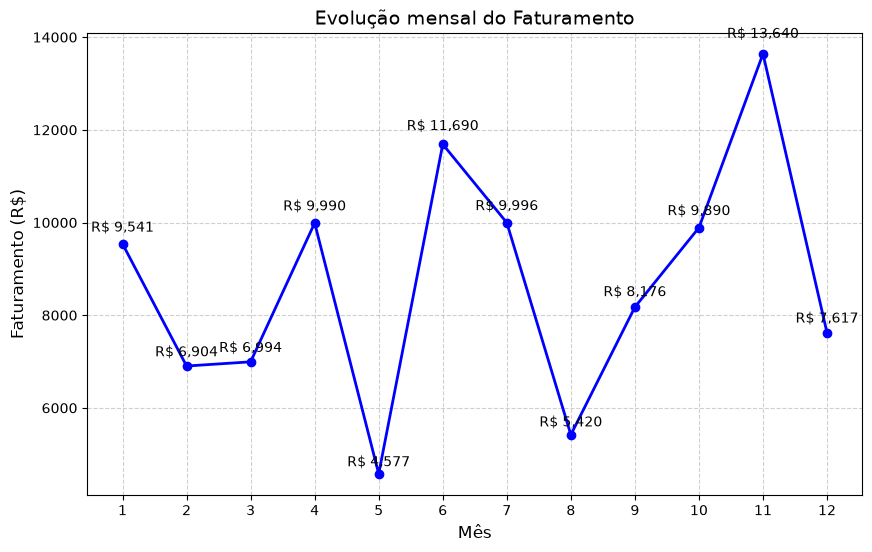

In [13]:
# 12

plt.figure(figsize=(10, 6))

faturamentomensal = df.groupby('mes')['faturamento'].sum().sort_index()

plt.plot(faturamentomensal.index, faturamentomensal.values, marker='o', color='b', linewidth=2)

for x, y in zip(faturamentomensal.index, faturamentomensal.values):
    plt.text(x, y + (y * 0.02), f'R$ {y:,.0f}', ha='center', va='bottom', fontsize=10)

plt.title('Evolução mensal do Faturamento', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(faturamentomensal.index) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

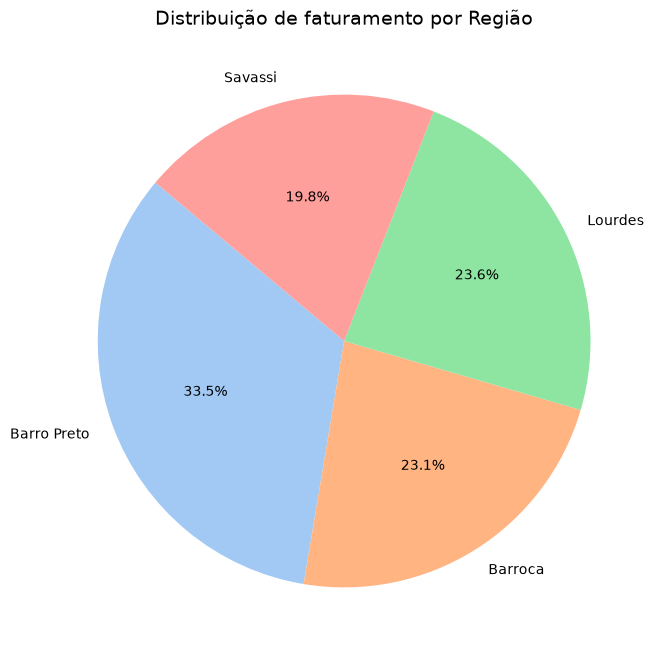

In [14]:
# 13

plt.figure(figsize=(8, 8))

faturamento_regiao = df.groupby('regiao')['faturamento'].sum()

plt.pie(faturamento_regiao, labels=faturamento_regiao.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribuição de faturamento por Região', fontsize=14)
plt.show()

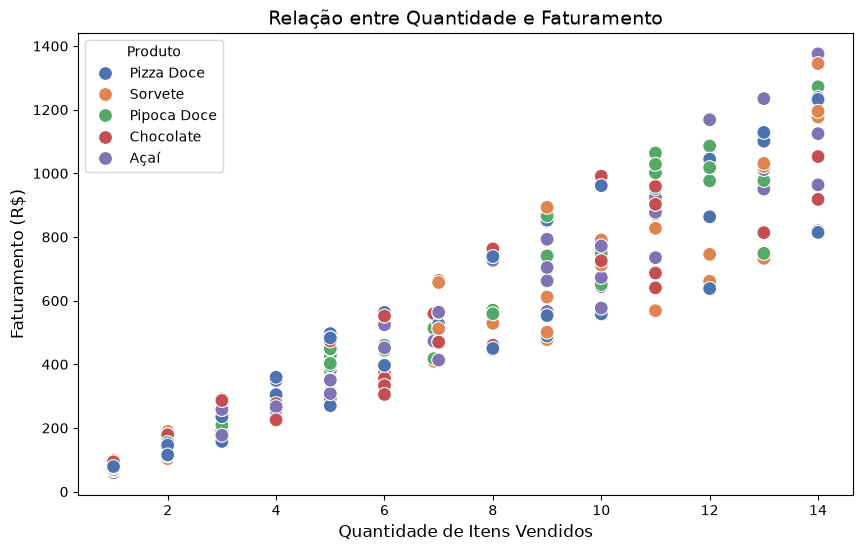

In [15]:
# 14

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='produto', s=100, palette='deep')

plt.title('Relação entre Quantidade e Faturamento', fontsize=14)
plt.xlabel('Quantidade de Itens Vendidos', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.legend(title='Produto')
plt.show()

C:\Users\22400206\AppData\Local\Temp\ipykernel_8816\4195612215.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria', y='preco_unitario', palette='Set2')


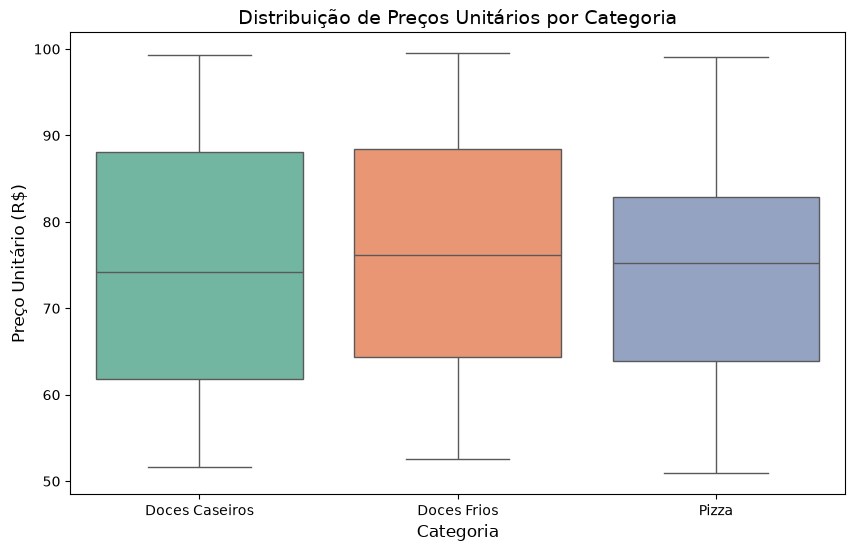

In [16]:
# 15

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='categoria', y='preco_unitario', palette='Set2')

plt.title('Distribuição de Preços Unitários por Categoria', fontsize=14)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Preço Unitário (R$)', fontsize=12)
plt.show()

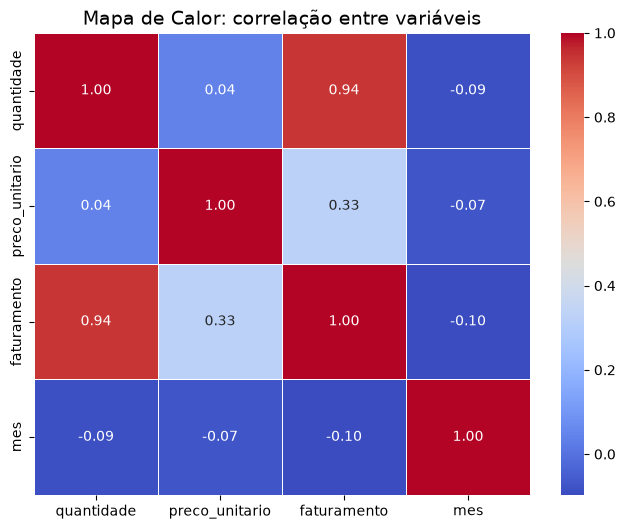

In [17]:
# 16

plt.figure(figsize=(8, 6))

colunasnumericas = df[['quantidade', 'preco_unitario', 'faturamento', 'mes']]
matrizcorrelacao = colunasnumericas.corr()

sns.heatmap(matrizcorrelacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor: correlação entre variáveis', fontsize=14)
plt.show()

## Etapa 4

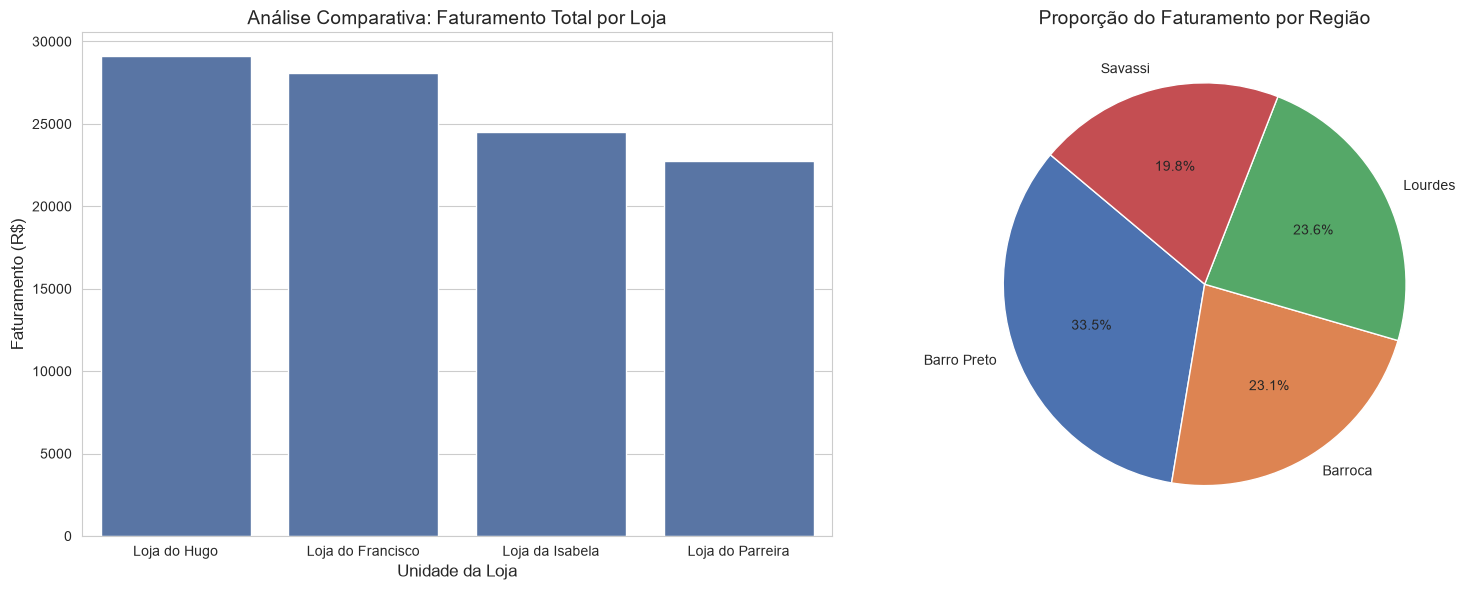

In [18]:
# 17

sns.set_style('whitegrid')
sns.set_palette(sns.color_palette('deep'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por loja
sns.barplot(x=faturamento_loja.index, y=faturamento_loja.values, ax=axes[0])
axes[0].set_title('Análise Comparativa: Faturamento Total por Loja', fontsize=14)
axes[0].set_xlabel('Unidade da Loja', fontsize=12)
axes[0].set_ylabel('Faturamento (R$)', fontsize=12)

# Por região
axes[1].pie(faturamento_regiao, labels=faturamento_regiao.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proporção do Faturamento por Região', fontsize=14)

plt.tight_layout()

# Salvando tudinho
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/layout_loja_regiao.png')

plt.show()

In [19]:
# 20

resumo_analitico = df.groupby('loja').agg(
    quantidade_vendida=('quantidade', 'sum'),
    faturamento_total=('faturamento', 'sum'),
    ticket_medio=('faturamento', lambda x: x.sum() / x.count())
).reset_index()

resumo_analitico = resumo_analitico.round(2)
resumo_analitico.to_csv('resumo_analitico.csv', index=False)

print("---------------------------------------------------")
print("Resumo Geral:")
print("---------------------------------------------------")
print("1. Através do gráfico de barras, ficou claro qual loja lidera as vendas gerais.")
print("2. O gráfico de pizza lado a lado revelou qual região tem a maior representatividade no faturamento.")
print("3. Confirmamos que existe uma correlação direta entre o preço unitário e o faturamento final.")
print("4. Conseguimos observar a variação de preços dentro das categorias, identificando se há produtos com valores muito fora do padrão.")

---------------------------------------------------
Resumo Geral:
---------------------------------------------------
1. Através do gráfico de barras, ficou claro qual loja lidera as vendas gerais.
2. O gráfico de pizza lado a lado revelou qual região tem a maior representatividade no faturamento.
3. Confirmamos que existe uma correlação direta entre o preço unitário e o faturamento final.
4. Conseguimos observar a variação de preços dentro das categorias, identificando se há produtos com valores muito fora do padrão.
